# 🌍 Land Cover Classifier — Random Forest vs XGBoost

**Pregunta que responde:** ¿Puede un modelo distinguir distintos tipos de cobertura de suelo (bosque, cultivo, zona urbana, agua, etc.) a partir de datos de imagen satelital?

**Stack:** Python, Pillow, scikit-learn, XGBoost

**Datos:** [EuroSAT — Sentinel-2 RGB](https://www.kaggle.com/datasets/raoofnaushad/eurosat-sentinel2-dataset) (Kaggle, vía kagglehub) — imágenes `.jpg` RGB, 10 clases, clase codificada en el nombre del archivo. **Sin dependencias externas en tiempo de ejecución.**

**Nota técnica:** este mirror entrega RGB (no las 13 bandas multiespectrales originales de EuroSAT), por lo que no hay banda NIR para NDVI/NDWI clásicos. En su lugar usamos **ExG (Excess Green)** y **VARI (Visible Atmospherically Resistant Index)** — índices de vegetación estándar cuando solo se dispone de luz visible.

**Autora:** Macarena Elizabeth Rios Zaldivar

---
## Índice
1. Setup y descarga del dataset (kagglehub)
2. Exploración de la estructura del dataset
3. Feature engineering: de imágenes RGB a vectores tabulares
4. Construcción del dataset de entrenamiento
5. Entrenamiento: Random Forest
6. Entrenamiento: XGBoost
7. Comparación de métricas (matriz de confusión, F1 por clase)
8. Importancia de features
9. Conclusiones y próximos pasos

## 1. Setup y descarga del dataset (kagglehub)

Dataset: **[EuroSAT Sentinel-2 Dataset](https://www.kaggle.com/datasets/raoofnaushad/eurosat-sentinel2-dataset)**

`kagglehub` viene preinstalado en Colab y maneja la autenticación de forma directa.

In [9]:
!pip install kagglehub -q

In [10]:
import kagglehub

path = kagglehub.dataset_download('raoofnaushad/eurosat-sentinel2-dataset')
print('Path to dataset files:', path)

Using Colab cache for faster access to the 'eurosat-sentinel2-dataset' dataset.
Path to dataset files: /kaggle/input/eurosat-sentinel2-dataset


In [11]:
import os

# Exploración rápida de la estructura descargada
for root, dirs, filenames in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root) or "."}/')
    if level < 2:
        for f in filenames[:5]:
            print(f'{indent}  {f}')

eurosat-sentinel2-dataset/
  Dataset/
    Forest_2838.jpg
    AnnualCrop_1184.jpg
    River_1705.jpg
    HerbaceousVegetation_1224.jpg
    HerbaceousVegetation_1712.jpg


In [12]:
!pip install pillow scikit-learn xgboost -q

## 2. Exploración de la estructura del dataset

Confirmado: las imágenes están en `<path>/1/Dataset/`, todas juntas (sin subcarpetas por clase), con el nombre de archivo en formato `Clase_numero.jpg`.

In [13]:
import re
import glob

DATA_DIR = os.path.join(path, 'Dataset')
# TODO: si esta ruta no existe, ajustar según la exploración de la sección 1

all_files = glob.glob(os.path.join(DATA_DIR, '*.jpg'))
print('Total de imágenes encontradas:', len(all_files))

def extraer_clase(filename):
    """Extrae el nombre de clase del filename tipo 'Pasture_1568.jpg' -> 'Pasture'."""
    base = os.path.basename(filename)
    match = re.match(r'^(.*)_\d+\.jpg$', base)
    return match.group(1) if match else None

class_names = sorted(set(extraer_clase(f) for f in all_files))
print('Clases encontradas:', class_names)

Total de imágenes encontradas: 27000
Clases encontradas: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 3. Feature engineering: de imágenes RGB a vectores tabulares

Reducimos cada imagen a un **vector de features**: media y desvío estándar de cada canal RGB, más ExG y VARI calculados sobre las medias — los índices de vegetación estándar cuando solo hay luz visible disponible (sin banda NIR).

In [14]:
from PIL import Image
import numpy as np

def extract_features(img_path):
    """Convierte una imagen RGB en un vector de features tabular."""
    img = np.array(Image.open(img_path).convert('RGB')).astype(float)
    # img shape: (alto, ancho, 3) -> canales R, G, B

    r_mean, g_mean, b_mean = img[:, :, 0].mean(), img[:, :, 1].mean(), img[:, :, 2].mean()
    r_std, g_std, b_std = img[:, :, 0].std(), img[:, :, 1].std(), img[:, :, 2].std()

    # ExG (Excess Green): resalta vegetación usando solo bandas visibles
    exg = 2 * g_mean - r_mean - b_mean
    # VARI (Visible Atmospherically Resistant Index): proxy de NDVI sin banda NIR
    vari = (g_mean - r_mean) / (g_mean + r_mean - b_mean + 1e-6)

    return np.array([r_mean, g_mean, b_mean, r_std, g_std, b_std, exg, vari])

feature_names = ['R_mean', 'G_mean', 'B_mean', 'R_std', 'G_std', 'B_std', 'ExG', 'VARI']
print(f'Total de features por muestra: {len(feature_names)}')

Total de features por muestra: 8


## 4. Construcción del dataset de entrenamiento

Recorremos todos los archivos, aplicamos `extract_features` a cada uno, y armamos el DataFrame final. Opcionalmente muestreamos un subconjunto por clase para iterar más rápido antes de correr sobre el dataset completo.

In [15]:
import pandas as pd
from collections import defaultdict

MAX_PER_CLASS = 500  # TODO: subir o quitar el límite cuando el pipeline esté validado

archivos_por_clase = defaultdict(list)
for f in all_files:
    clase = extraer_clase(f)
    if clase is not None:
        archivos_por_clase[clase].append(f)

rows = []
labels = []
for clase, archivos in archivos_por_clase.items():
    for archivo in archivos[:MAX_PER_CLASS]:
        rows.append(extract_features(archivo))
        labels.append(clase)

df = pd.DataFrame(rows, columns=feature_names)
df['class'] = labels
print(df.shape)
df['class'].value_counts()

(5000, 9)


,count
class,
Forest,500
AnnualCrop,500
River,500
HerbaceousVegetation,500
Pasture,500
Industrial,500
Residential,500
PermanentCrop,500
SeaLake,500


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['class'])
X = df[feature_names]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, ' Test:', X_test.shape)

Train: (4000, 8)  Test: (1000, 8)


## 5. Entrenamiento: Random Forest

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

## 6. Entrenamiento: XGBoost

In [18]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, random_state=42, eval_metric='mlogloss', n_jobs=-1)
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

## 7. Comparación de métricas

In [19]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

for nombre, modelo in [('Random Forest', rf), ('XGBoost', xgb)]:
    preds = modelo.predict(X_test)
    print(f'--- {nombre} ---')
    print(classification_report(y_test, preds, target_names=le.classes_))
    print('F1 macro:', f1_score(y_test, preds, average='macro'))
    print()

--- Random Forest ---
                      precision    recall  f1-score   support

          AnnualCrop       0.78      0.84      0.81       100
              Forest       0.91      0.91      0.91       100
HerbaceousVegetation       0.70      0.59      0.64       100
             Highway       0.44      0.44      0.44       100
          Industrial       0.81      0.90      0.85       100
             Pasture       0.79      0.88      0.83       100
       PermanentCrop       0.66      0.62      0.64       100
         Residential       0.71      0.74      0.73       100
               River       0.66      0.62      0.64       100
             SeaLake       0.96      0.90      0.93       100

            accuracy                           0.74      1000
           macro avg       0.74      0.74      0.74      1000
        weighted avg       0.74      0.74      0.74      1000

F1 macro: 0.741787621007633

--- XGBoost ---
                      precision    recall  f1-score   support


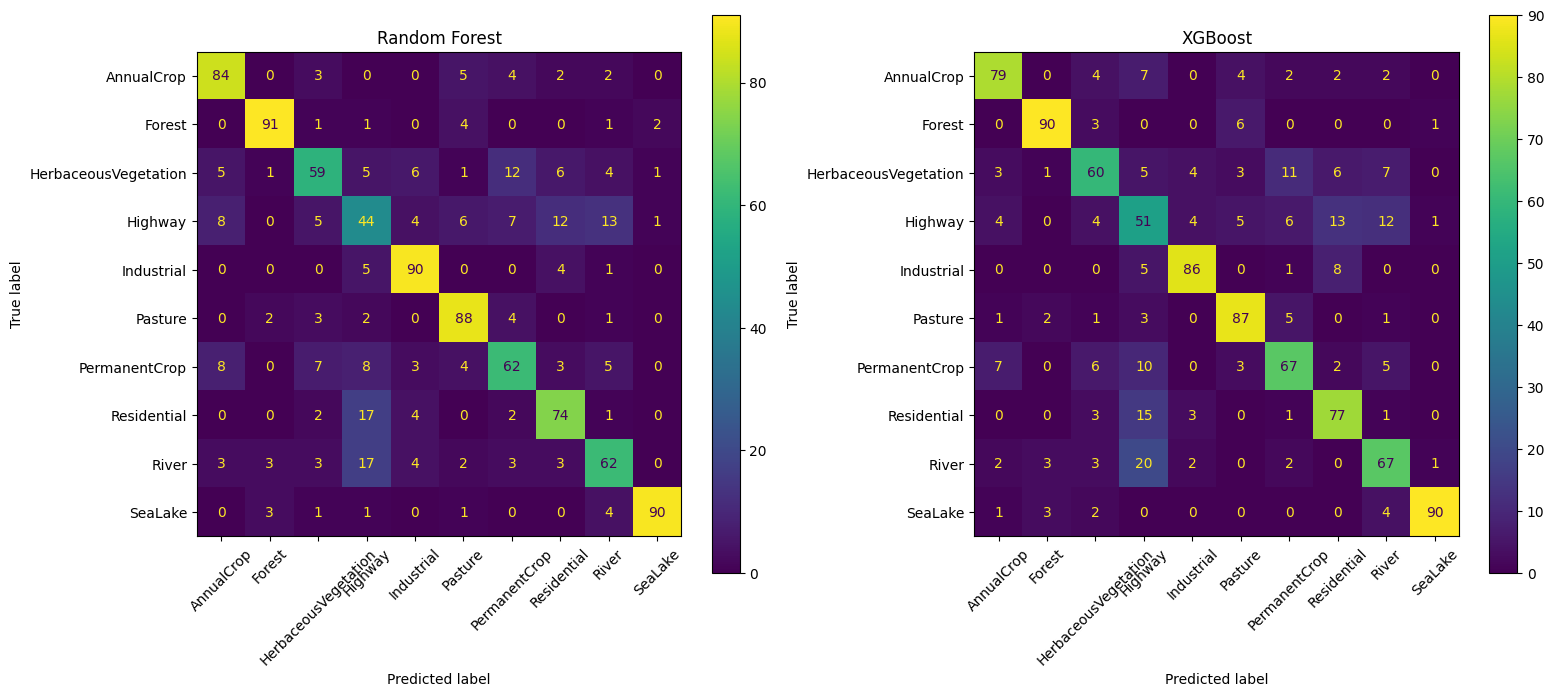

In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (nombre, modelo) in zip(axes, [('Random Forest', rf), ('XGBoost', xgb)]):
    preds = modelo.predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=le.classes_, ax=ax, xticks_rotation=45
    )
    ax.set_title(nombre)
plt.tight_layout()
plt.show()

## 8. Importancia de features

¿Qué canales/índices pesan más en la clasificación? Esto conecta directo con el storytelling del proyecto: mostrar razonamiento espectral, no solo métricas.

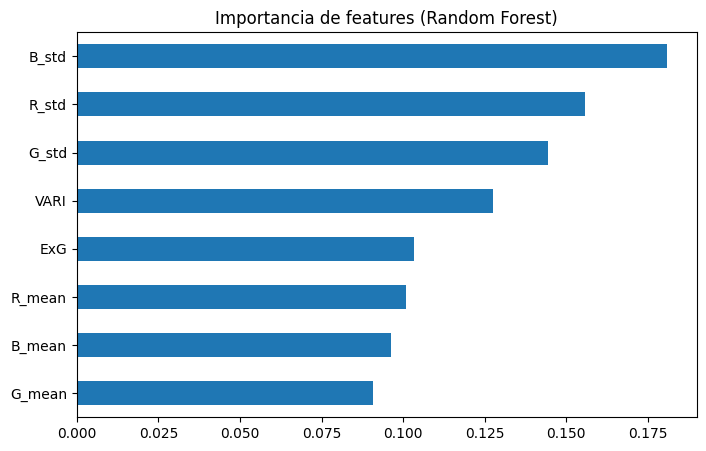

In [21]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title('Importancia de features (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

## 9. Conclusiones y próximos pasos

TODO: resumir qué modelo funcionó mejor, si ExG/VARI aparecen entre las features más importantes (buena señal de que el feature engineering espectral aporta valor real más allá de las medias de color crudas), y en qué clases se confunden más los modelos (ej. AnnualCrop vs PermanentCrop suelen ser difíciles de distinguir en RGB puro).

**Próxima iteración sugerida:** si se consigue la versión multiespectral real (13 bandas, con NIR) de EuroSAT, repetir el pipeline con NDVI/NDWI verdaderos y comparar si mejora la separación de clases frente a los proxies ExG/VARI usados acá — es un contraste interesante para el storytelling técnico del proyecto.